# Marigold-normals study — overview

Analyses the effect of using ESTIMATED (Marigold) normals instead of GT normals, on
`ct-ct_sh-frOn_env`. Reads `results/marigold_normal_study/<config>/<scene>/<source>/results.json`
(sources: `normal_000` = 1st Marigold map, `normal_avg` = averaged 16) and the canonical batch's
GT-normal runs (`results/canonical_ablation/ct_sh_env/<scene>/<config>`).

1. normal-map accuracy (per-image RMSE / angle, and the averaged map);
2. decomposition metrics: **GT normals vs Marigold-000 vs Marigold-avg**;
3. per-scene: normal-map estimates, a re-render under a training light (GT vs estimated normals),
   and the relight comparison (est-vs-GT intrinsics).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "idr").is_dir())
os.chdir(REPO)
for p in (str(REPO), str(REPO / "scripts")):
    if p not in sys.path: sys.path.insert(0, p)
os.environ.setdefault("WANDB_MODE", "disabled")
from idr.paths import RESULTS_DIR
STUDY_ROOT = RESULTS_DIR / "marigold_normal_study"
CANON_ROOT = RESULTS_DIR / "canonical_ablation" / "ct_sh_env"
DEVICE = "cuda"
CONFIG = sorted(p.name for p in STUDY_ROOT.iterdir() if p.is_dir())[0] if STUDY_ROOT.exists() else "light_mono"
print("study root:", STUDY_ROOT, "| config:", CONFIG)

study root: /home/felix/Projects/image-intrinsics/results/marigold_normal_study | config: light_mono


## 1. Load — Marigold runs + GT-normal baseline

In [3]:
MET = ["recon_rmse","albedo_rmse","roughness_rmse","metallic_rmse","relighting_rmse"]
def load_all(config=CONFIG):
    rows = []
    for p in sorted((STUDY_ROOT/config).glob("*/*/results.json")):
        r = json.loads(p.read_text()); m = r["metrics"]
        row = dict(scene=r["scene"], source=r["source"], out_dir=r["out_dir"], scene_dir=r["scene_dir"],
                   normal_rmse=m.get("normal_map_rmse"), normal_angle=m.get("normal_map_angle"),
                   per_image_rmse_mean=m.get("per_image_rmse_mean"),
                   per_image_angle_mean=m.get("per_image_angle_mean"),
                   avg_map_rmse=m.get("avg_map_rmse"), avg_map_angle=m.get("avg_map_angle"))
        row.update({k: m.get(k) for k in MET}); rows.append(row)
    # GT-normal baseline from the canonical batch (same config, same dataset)
    for p in sorted(CANON_ROOT.glob(f"*/{config}/results.json")):
        r = json.loads(p.read_text()); m = r["metrics"]
        row = dict(scene=r["scene"], source="GT_normals", out_dir=r["out_dir"], scene_dir=r["scene_dir"],
                   normal_rmse=0.0, normal_angle=0.0)
        row.update({k: m.get(k) for k in MET}); rows.append(row)
    df = pd.DataFrame(rows)
    if df.empty: raise SystemExit(f"no results under {STUDY_ROOT/config} — run scripts/marigold_normals_sh3.py")
    return df

df = load_all()
print(f"{len(df)} run(s) | sources={sorted(df.source.unique())} | scenes={df.scene.nunique()}")
df.groupby("source").size()

201 run(s) | sources=['GT_normals', 'normal_000', 'normal_avg'] | scenes=67


source
GT_normals    67
normal_000    67
normal_avg    67
dtype: int64

## 2a. Normal-map accuracy

Per-image RMSE (16 predictions/scene), the averaged map, and the 1st map — how good are the
Marigold normals, and does averaging help?

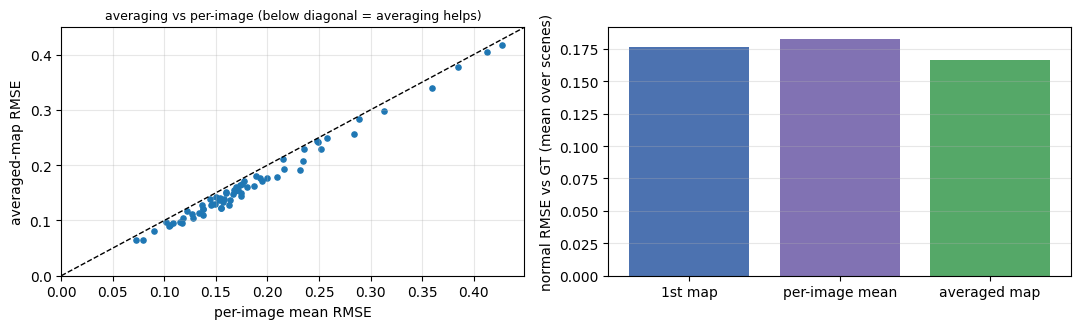

In [4]:
sub = df[df.source=="normal_000"].dropna(subset=["per_image_rmse_mean"])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].scatter(sub.per_image_rmse_mean, sub.avg_map_rmse, s=14)
lim=[0, float(max(sub.per_image_rmse_mean.max(), sub.avg_map_rmse.max()))*1.05]
ax[0].plot(lim, lim, "k--", lw=1); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("per-image mean RMSE"); ax[0].set_ylabel("averaged-map RMSE")
ax[0].set_title("averaging vs per-image (below diagonal = averaging helps)", fontsize=9); ax[0].grid(alpha=0.3)
ax[1].bar(["1st map","per-image mean","averaged map"],
          [df[df.source=="normal_000"].normal_rmse.mean(), sub.per_image_rmse_mean.mean(), sub.avg_map_rmse.mean()],
          color=["#4C72B0","#8172B3","#55A868"])
ax[1].set_ylabel("normal RMSE vs GT (mean over scenes)"); ax[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 2b. Decomposition: GT normals vs Marigold-000 vs Marigold-avg

Same config + split; the only difference is the normal source. Higher bars for the Marigold
sources = the cost of estimating normals.

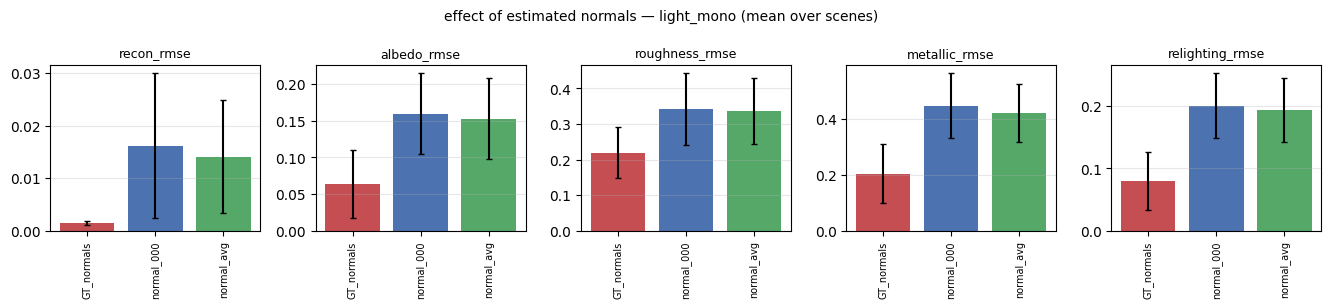

,recon_rmse,albedo_rmse,roughness_rmse,metallic_rmse,relighting_rmse
source,,,,,
GT_normals,0.0015,0.0639,0.2197,0.2042,0.0795
normal_000,0.0162,0.1598,0.3407,0.4460,0.2007
normal_avg,0.0141,0.1529,0.3362,0.4197,0.1938


In [5]:
ORDER = ["GT_normals","normal_000","normal_avg"]
def decomp_compare(df):
    srcs = [s for s in ORDER if s in set(df.source)]
    x = np.arange(len(srcs))
    fig, ax = plt.subplots(1, len(MET), figsize=(2.7*len(MET), 3.1), squeeze=False)
    for ci, met in enumerate(MET):
        a = ax[0][ci]
        means=[df[df.source==s][met].mean() for s in srcs]; stds=[df[df.source==s][met].std() for s in srcs]
        a.bar(x, means, yerr=stds, capsize=2, color=["#C44E52","#4C72B0","#55A868"][:len(srcs)])
        a.set_xticks(x); a.set_xticklabels(srcs, rotation=90, fontsize=7); a.set_title(met, fontsize=9)
        a.grid(axis="y", alpha=0.3)
    fig.suptitle(f"effect of estimated normals — {CONFIG} (mean over scenes)", fontsize=10)
    plt.tight_layout(); plt.show()
decomp_compare(df)
df.groupby("source")[MET].mean().round(4)

## 3. Per-scene visuals (on demand)

In [17]:
SCENE = df.scene.iloc[5]
SOURCE = "normal_000"
def resolve(scene, source, df=df):
    hit=df[(df.scene==scene)&(df.source==source)]
    if hit.empty: raise SystemExit(f"no run for {scene}/{source}")
    r=hit.iloc[0]; return Path(r.out_dir), Path(r.scene_dir)
RUN_DIR, SCENE_DIR = resolve(SCENE, SOURCE); DS = 1
print(RUN_DIR)

/home/felix/Projects/image-intrinsics/results/marigold_normal_study/light_mono/1c349305_v2/normal_000


### Normal-map estimates (GT vs Marigold-000 vs averaged) + error

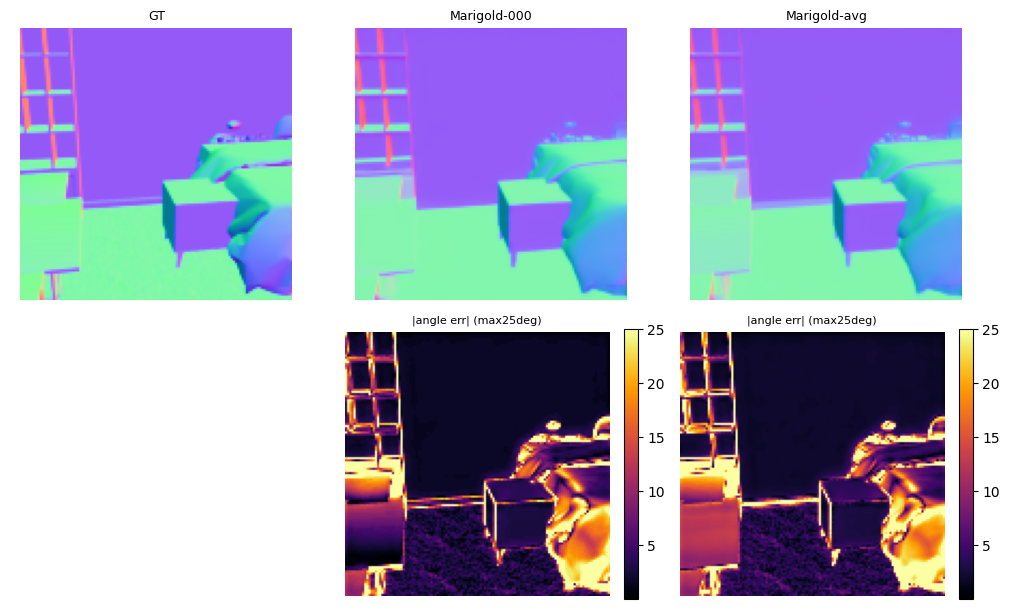

In [18]:
from PIL import Image
from marigold_normals_sh3 import marigold_maps, averaged_map, _decode_normal
from idr.data.scene_io import load_scene
gtn = load_scene(SCENE_DIR, gt_npy=True)["normals_np"]; mask = np.linalg.norm(gtn,axis=-1)>0.5
maps = marigold_maps(SCENE_DIR); avg = averaged_map(maps)
def nrgb(n): im=(n*0.5+0.5).clip(0,1); im[np.linalg.norm(n,axis=-1)<0.5]=0; return im
def aerr(n): 
    d=(n*gtn).sum(-1).clip(-1,1); e=np.degrees(np.arccos(d))*mask; return e
cols=[("GT",gtn),("Marigold-000",maps[0]),("Marigold-avg",avg)]
fig,ax=plt.subplots(2,len(cols),figsize=(3.4*len(cols),6.2))
for j,(t,n) in enumerate(cols):
    ax[0][j].imshow(nrgb(n)); ax[0][j].set_title(t,fontsize=9); ax[0][j].axis("off")
    if j==0: ax[1][j].axis("off")
    else:
        h=ax[1][j].imshow(aerr(n),cmap="inferno",vmax=25); ax[1][j].set_title(f"|angle err| (max25deg)",fontsize=8); ax[1][j].axis("off")
        plt.colorbar(h,ax=ax[1][j],fraction=0.046)
plt.tight_layout(); plt.show()

### Re-render under a training light (GT intrinsics): GT normals vs estimated normals

Renders the GT intrinsics under training light 0's GT SH with each geometry — how much the
wrong normals alone change the exact image the decomposition was fit to.

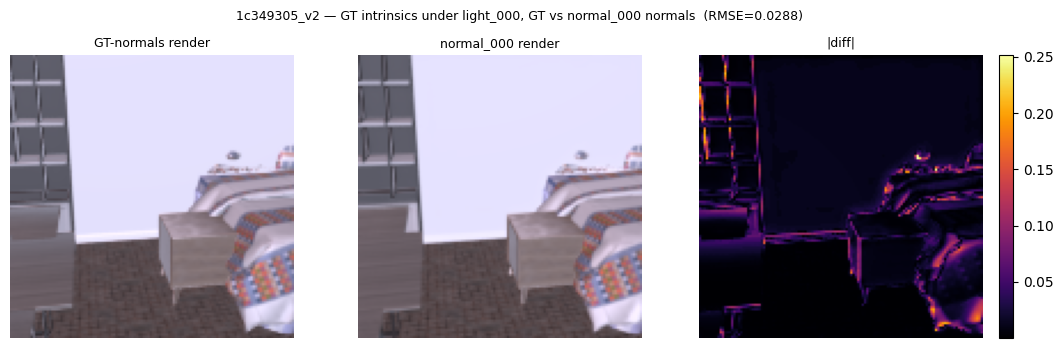

In [19]:
from canonical_relight_render import Relighter, load_gt_intrinsics
gt = load_gt_intrinsics(SCENE_DIR, DS); sh0 = load_scene(SCENE_DIR, gt_npy=True)["sh_coeffs"][0]
est_n = maps[0] if SOURCE=="normal_000" else avg
r_gt  = Relighter(gtn,   mask, DEVICE).render_sh(gt, sh0)
r_est = Relighter(est_n, mask, DEVICE).render_sh(gt, sh0)
def tm(x): s=np.percentile(r_gt[mask],99.5) or 1; return np.clip(x/s,0,1)**(1/2.2)
err=np.abs(r_gt-r_est).mean(-1)*mask
fig,ax=plt.subplots(1,3,figsize=(11,3.5))
for a,(t,im,cm) in zip(ax,[("GT-normals render",tm(r_gt),None),(f"{SOURCE} render",tm(r_est),None),("|diff|",err,"inferno")]):
    h=a.imshow(im,cmap=cm); a.set_title(t,fontsize=9); a.axis("off")
    if cm: plt.colorbar(h,ax=a,fraction=0.046)
fig.suptitle(f"{SCENE} — GT intrinsics under light_000, GT vs {SOURCE} normals  (RMSE={np.sqrt((( r_gt-r_est)[mask]**2).mean()):.4f})",fontsize=9)
plt.tight_layout(); plt.show()

### Relight: estimated intrinsics (from the Marigold-normal decomp) vs GT

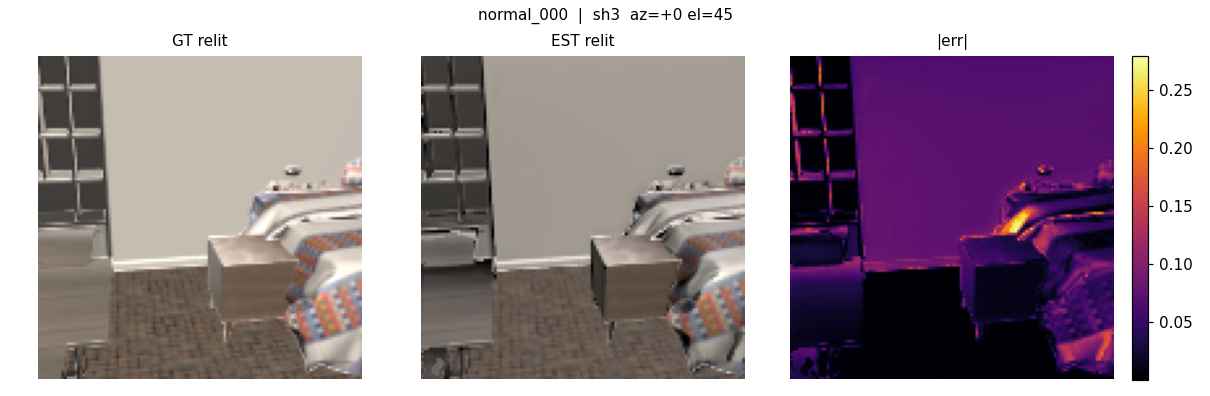

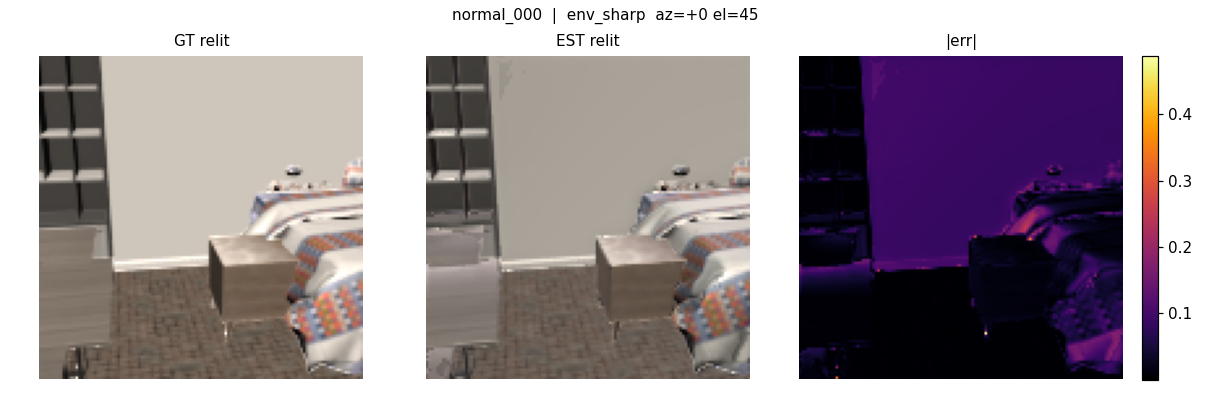

In [20]:
from canonical_relight_render import render_comparison
from IPython.display import Image as IPyImage, display
for mode in ("sh3","env_sharp"):
    display(IPyImage(filename=render_comparison(RUN_DIR, SCENE_DIR, mode=mode, az=0., el=45., ds=DS, device=DEVICE)))